In [1]:
import os
import torch
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import sys
sys.path.insert(0, '../../src')
import utils

In [2]:
# ── Configure ──────────────────────────────────────────────────────────────────
results_path = '../../outputs/fiducial/mdp_output/sensitivity_results.pt'
figures_dir  = '../../figures/fiducial/sensitivity'
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(figures_dir, exist_ok=True)

res = torch.load(results_path, weights_only=False)

rho_S_range      = np.array(res['rho_S_range'])       # (n_rho,)
theta_star_range = np.array(res['theta_star_range'])   # (n_theta,)
eps_star         = np.array(res['eps_star'])           # (n_rho,)
us_mdp           = np.array(res['us_mdp'])             # (n_rho,)
P_mdp            = np.array(res['P_mdp'])              # (n_rho,)
A_mdp            = np.array(res['A_mdp'])              # (n_rho,)
P_true           = np.array(res['P_true'])             # (n_rho, n_theta)
A_true           = np.array(res['A_true'])             # (n_rho, n_theta)
p_optout_true    = np.array(res['p_optout_true'])      # (n_rho, n_theta)
us_true          = np.array(res['us_true'])            # (n_rho, n_theta)
params           = res['params']

print('Parameters:')
for k, v in params.items():
    print(f'  {k}: {v}')
print(f'\nrho_S values  : {rho_S_range.tolist()}')
print(f'theta* values : {theta_star_range.tolist()}')

Parameters:
  rho_A: 240
  T: 3
  n_max: 200
  c0: 48.9
  c1: 0.066
  kappa: 0.05
  theta_b: 0.5
  alpha_0: 1.0
  beta_0: 1.0
  device: cuda
  epsilon_max: 0.9
  tol: 1e-06
  n_episodes: 200000
  theta_fid: 0.65

rho_S values  : [240.0, 500.0, 1000.0, 2000.0, 3000.0, 4000.0, 5000.0, 6000.0, 7000.0, 8000.0, 9000.0, 10000.0]
theta* values : [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.85, 0.9]


## 1. Optimal subsidy $\varepsilon^*$ vs $\rho_S$

For each value of the social utility of approval $\rho_S$, Algorithm 1 (divide-and-conquer) finds the subsidy $\varepsilon^*$ that maximises the principal's expected social utility $U^S = \rho_S P_{\text{approval}} - \varepsilon^* A$ under the MDP's Beta-Binomial dynamics.

In [4]:
# ── Compute: optimal-subsidy / %-gain bootstrap CIs and diagnostics ─────────
#
# Split out from the plot cell below so stylistic tweaks don't re-trigger the
# bootstrap. Produces: x_ratio, rho_A_val, eps_ss_opt, pct_a_fid, pct_b_fid,
# yerr_a, yerr_b, n_star_ss0, n_star_ssopt, n_max_ss, j_fid.

rho_A_val = float(params['rho_A'])
x_ratio = rho_S_range / rho_A_val

# ── Load single-shot baseline ────────────────────────────────────────────────
ss_path = '../../outputs/single_shot/baseline/single_shot_baseline.pt'
ss = torch.load(ss_path, weights_only=False)
assert ss['rho_S_range']      == rho_S_range.tolist()
assert ss['theta_star_range'] == theta_star_range.tolist()

us_ss0_    = np.array(ss['us_true_ss0'])
us_ssopt_  = np.array(ss['us_true_ss_epsopt'])
P_ss0_     = np.array(ss['P_true_ss0'])
A_ss0_     = np.array(ss['A_true_ss0'])
P_ssopt_   = np.array(ss['P_true_ss_epsopt'])
A_ssopt_   = np.array(ss['A_true_ss_epsopt'])
eps_ss_opt = np.array(ss['eps_ss_opt'])

theta_fid = 0.65
j_fid = int(np.argmin(np.abs(theta_star_range - theta_fid)))
assert abs(theta_star_range[j_fid] - theta_fid) < 1e-9, \
    f'theta*=0.65 not in theta_star_range: {theta_star_range.tolist()}'

def _pct_gain(num, den):
    return np.where(np.abs(den) > 1e-12, (num - den) / den * 100.0, np.nan)

pct_a_fid = _pct_gain(us_true[:, j_fid], us_ss0_[:,   j_fid])
pct_b_fid = _pct_gain(us_true[:, j_fid], us_ssopt_[:, j_fid])

# ── Bootstrap 95% CIs on the %-gain, using per-episode MC samples ───────────
# samples_fid_*    : (n_rho, n_ep) from sensitivity_analysis
# samples_ss0_*    : (n_ep,)       from single_shot_baseline (policy rho_S-independent)
# samples_ssopt_*  : (n_rho, n_ep) from single_shot_baseline (policy per rho_S)
_fid_ap = np.asarray(res['samples_fid_approved'])            # (n_rho, n_ep) int8
_fid_co = np.asarray(res['samples_fid_cost']).astype(np.float64)
_ss0_ap = np.asarray(ss['samples_ss0_approved'])             # (n_ep,) int8
_sso_ap = np.asarray(ss['samples_ssopt_approved'])           # (n_rho, n_ep) int8
_sso_co = np.asarray(ss['samples_ssopt_cost']).astype(np.float64)

n_ep_fid = _fid_ap.shape[1]
n_ep_ss  = _ss0_ap.shape[0]
n_rho_   = len(rho_S_range)
B        = 1000          # bootstrap replicates
batch    = 50            # vectorisation batch (controls peak memory)
boot_rng = np.random.default_rng(0)

pct_a_fid_lo = np.full(n_rho_, np.nan)
pct_a_fid_hi = np.full(n_rho_, np.nan)
pct_b_fid_lo = np.full(n_rho_, np.nan)
pct_b_fid_hi = np.full(n_rho_, np.nan)

def _boot_means(samples_1d, B, batch, rng):
    n = len(samples_1d)
    out = np.empty(B)
    for s in range(0, B, batch):
        e = min(s + batch, B)
        idx = rng.integers(0, n, size=(e - s, n))
        out[s:e] = samples_1d[idx].mean(axis=1)
    return out

for i_ in range(n_rho_):
    rho_S_i = rho_S_range[i_]
    eps_fid_i = eps_star[i_]
    eps_sso_i = eps_ss_opt[i_]
    u_true_s  = rho_S_i * _fid_ap[i_].astype(np.float64) - eps_fid_i * _fid_co[i_]
    u_ss0_s   = rho_S_i * _ss0_ap.astype(np.float64)  # eps=0
    u_ssopt_s = rho_S_i * _sso_ap[i_].astype(np.float64) - eps_sso_i * _sso_co[i_]

    m_true  = _boot_means(u_true_s,  B, batch, boot_rng)
    m_ss0   = _boot_means(u_ss0_s,   B, batch, boot_rng)
    m_ssopt = _boot_means(u_ssopt_s, B, batch, boot_rng)

    pct_a_b = np.where(np.abs(m_ss0)   > 1e-12, (m_true - m_ss0)   / m_ss0   * 100.0, np.nan)
    pct_b_b = np.where(np.abs(m_ssopt) > 1e-12, (m_true - m_ssopt) / m_ssopt * 100.0, np.nan)
    pct_a_fid_lo[i_], pct_a_fid_hi[i_] = np.nanquantile(pct_a_b, [0.025, 0.975])
    pct_b_fid_lo[i_], pct_b_fid_hi[i_] = np.nanquantile(pct_b_b, [0.025, 0.975])

yerr_a = np.vstack([pct_a_fid - pct_a_fid_lo, pct_a_fid_hi - pct_a_fid])
yerr_b = np.vstack([pct_b_fid - pct_b_fid_lo, pct_b_fid_hi - pct_b_fid])


# Recover n*(0,0) for diagnostics
c0 = float(params['c0']); c1 = float(params['c1'])

def _recover_n_star(A_row, P_row):
    p = P_row[j_fid]; a = A_row[j_fid]
    if p <= 0:
        return float('nan')
    return (a / p - c0) / c1

n_star_ss0   = np.array([_recover_n_star(A_ss0_[i],   P_ss0_[i])   for i in range(len(rho_S_range))])
n_star_ssopt = np.array([_recover_n_star(A_ssopt_[i], P_ssopt_[i]) for i in range(len(rho_S_range))])

n_max_ss = int(ss['params']['n_max'])
print(f"Single-shot n_max = {n_max_ss}   rho_A = {rho_A_val}")
print(f"{'rho_S':>8}  {'rho_S/rho_A':>12}  {'eps*_fid':>10}  {'eps*_ss':>10}  {'n* (eps=0)':>11}  {'n* (eps=eps*_ss)':>18}")
print('-' * 80)
for i, rho_S in enumerate(rho_S_range):
    print(f"{rho_S:8.1f}  {x_ratio[i]:12.3f}  {eps_star[i]:10.4f}  {eps_ss_opt[i]:10.4f}  "
          f"{n_star_ss0[i]:11.2f}  {n_star_ssopt[i]:18.2f}")


Single-shot n_max = 800   rho_A = 240.0
   rho_S   rho_S/rho_A    eps*_fid     eps*_ss   n* (eps=0)    n* (eps=eps*_ss)
--------------------------------------------------------------------------------
   240.0         1.000      0.0000      0.0000        87.00               87.00
   500.0         2.083      0.0000      0.0794        87.00              108.00
  1000.0         4.167      0.1079      0.0794        87.00              108.00
  2000.0         8.333      0.1079      0.0794        87.00              108.00
  3000.0        12.500      0.1079      0.0794        87.00              108.00
  4000.0        16.667      0.1079      0.6774        87.00              129.00
  5000.0        20.833      0.2263      0.6774        87.00              129.00
  6000.0        25.000      0.2263      0.6774        87.00              129.00
  7000.0        29.167      0.2263      0.6774        87.00              129.00
  8000.0        33.333      0.3148      0.6774        87.00              129.00

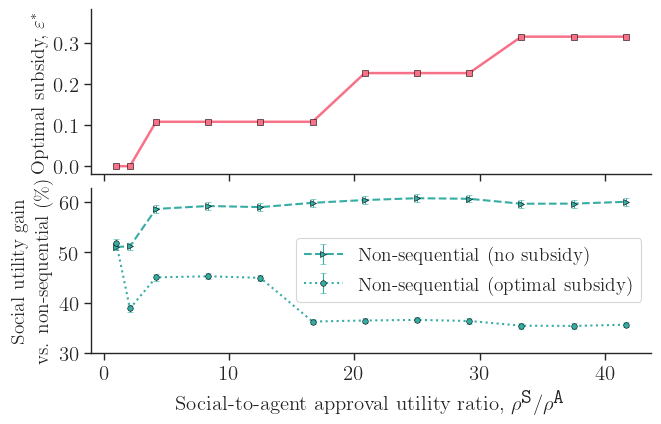

In [17]:
# ── Plot: optimal subsidy (top) + %-utility gain (bottom) ───────────────────
# Uses precomputed values from the compute cell above.

sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()

width_pt = 950
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(fig_width, fig_height ),
                                      sharex=True,
                                      gridspec_kw={'hspace': 0.08}
                                      )

palette = sns.color_palette('husl', n_colors=4)

# ── Top panel: optimal subsidy ──────────────────────────────────────────────
ax_top.plot(x_ratio, eps_star, 's-', color=palette[0],
            linewidth=1.8, markersize=5, label=r'$\varepsilon^*(\rho_S)$ (MDP)',
            markeredgecolor='black', markeredgewidth=0.4)
ax_top.set_ylabel(r'Optimal subsidy, $\varepsilon^*$', fontsize=14)
ax_top.set_ylim(-0.02, max(eps_star) * 1.15 + 0.02)
ax_top.set_yticks([0, 0.1, 0.2, 0.3])
#Set fontsize for ticklabels to 10
ax_top.tick_params(axis='both', labelsize=15)
#ax_top.legend(fontsize=15, loc='upper left')
sns.despine(ax=ax_top)

# ── Bottom panel: % utility gain ─────────────────────────────────────────────
ax_bot.errorbar(x_ratio, pct_a_fid, yerr=yerr_a, fmt='>--', color=palette[2],
                linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                ecolor=palette[2], elinewidth=0.8, capsize=2.5,
                label=r'Non-sequential (no subsidy)')
ax_bot.errorbar(x_ratio, pct_b_fid, yerr=yerr_b, fmt='o:', color=palette[2],
                linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                ecolor=palette[2], elinewidth=0.8, capsize=2.5,
                label=r'Non-sequential (optimal subsidy)')

ax_bot.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=15)
ax_bot.set_ylabel(
    r'$\begin{array}{c}\textrm{Social utility gain} \\ \textrm{vs. non-sequential}\ (\%)\end{array}$',
    fontsize=14,
    labelpad=20,
    rotation=90,
    va='center'
)

ax_bot.set_yticks([30,40,50,60])

#Set at ticks to 15
ax_bot.tick_params(axis='both', labelsize=15)
ax_top.tick_params(axis='both', labelsize=15)

ax_bot.set_ylim(bottom=30)
ax_bot.legend(fontsize=14, loc='best')
sns.despine(ax=ax_bot)

#plt.tight_layout()
plt.show()

fig.subplots_adjust(
    left=0.12,
    right=0.88,   # leave space for colorbar in Code 2
    top=0.95,
    bottom=0.15
)

fig.savefig(os.path.join(figures_dir, 'eps_star_vs_rhoS.pdf'))


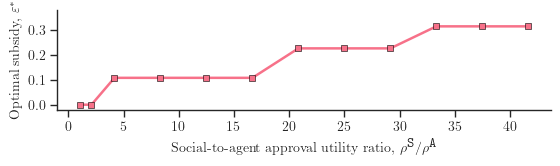

In [4]:
# ── Panel A only: optimal subsidy epsilon* vs rho_S/rho_A ────────────────────
fig_top, ax_top_only = plt.subplots(figsize=(fig_width, fig_height / 2))

ax_top_only.plot(x_ratio, eps_star, 's-', color=palette[0],
                 linewidth=1.8, markersize=5, label=r'$\varepsilon^*(\rho_S)$ (MDP)',
                 markeredgecolor='black', markeredgewidth=0.4)
ax_top_only.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=10)
ax_top_only.set_ylabel(r'Optimal subsidy, $\varepsilon^*$', fontsize=10)
ax_top_only.set_ylim(-0.02, max(eps_star) * 1.15 + 0.02)
ax_top_only.set_yticks([0, 0.1, 0.2, 0.3])
ax_top_only.tick_params(axis='both', labelsize=10)
sns.despine(ax=ax_top_only)
fig_top.tight_layout()
plt.show()
fig_top.savefig(os.path.join(figures_dir, 'eps_star_vs_rhoS_top.pdf'), bbox_inches='tight')


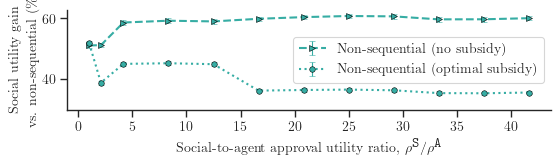

In [5]:
# ── Panel B only: % social utility gain vs non-sequential baseline ──────────
fig_bot, ax_bot_only = plt.subplots(figsize=(fig_width, fig_height / 2))

label_a = r'Non-sequential (no subsidy)' if not np.any(np.isnan(pct_a_fid)) else '_nolegend_'
ax_bot_only.errorbar(x_ratio, pct_a_fid, yerr=yerr_a, fmt='>--', color=palette[2],
                     linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                     ecolor=palette[2], elinewidth=0.8, capsize=2.5,
                     label=label_a)
ax_bot_only.errorbar(x_ratio, pct_b_fid, yerr=yerr_b, fmt='o:', color=palette[2],
                     linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                     ecolor=palette[2], elinewidth=0.8, capsize=2.5,
                     label=r'Non-sequential (optimal subsidy)')

ax_bot_only.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=10)
ax_bot_only.set_ylabel(
    r'$\begin{array}{c}\textrm{Social utility gain} \\ \textrm{vs. non-sequential}\ (\%)\end{array}$',
    fontsize=10, labelpad=12, rotation=90, va='center')
ax_bot_only.set_ylim(bottom=30)
ax_bot_only.tick_params(axis='both', labelsize=10)
ax_bot_only.legend(fontsize=10, loc='best')
sns.despine(ax=ax_bot_only)
fig_bot.tight_layout()
plt.show()
fig_bot.savefig(os.path.join(figures_dir, 'pct_gain_vs_rhoS_bot.pdf'), bbox_inches='tight')


## 1b. Same plot for $\theta^* \in \{0.30, 0.85\}$ (means only, no CIs)

Per-episode samples were only stored at `theta_fid=0.65`, so bootstrap CIs are unavailable for other $\theta^*$ without re-running the analyses. The cell below reproduces the two-panel figure using aggregate means from the existing `.pt` files.


--- theta* = 0.3 ---


/tmp/ipykernel_4048399/4128655555.py:48: RuntimeWarning: invalid value encountered in divide
  return np.where(np.abs(den) > 1e-12, (num - den) / den * 100.0, np.nan)


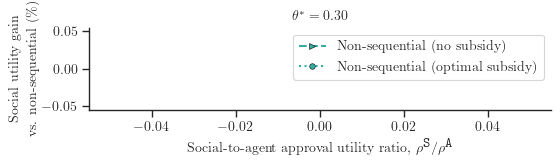

   rho_S   rho_S/rho_A   gain_vs_ss0_%   gain_vs_ssopt_%
   240.0         1.000             nan               nan
   500.0         2.083             nan               nan
  1000.0         4.167             nan               nan
  2000.0         8.333             nan               nan
  3000.0        12.500             nan               nan
  4000.0        16.667             nan               nan
  5000.0        20.833             nan               nan
  6000.0        25.000             nan               nan
  7000.0        29.167             nan               nan
  8000.0        33.333             nan               nan
  9000.0        37.500             nan               nan
 10000.0        41.667             nan               nan

--- theta* = 0.85 ---


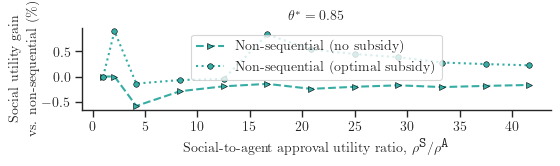

   rho_S   rho_S/rho_A   gain_vs_ss0_%   gain_vs_ssopt_%
   240.0         1.000          0.0005            0.0005
   500.0         2.083          0.0005            0.8974
  1000.0         4.167         -0.5836           -0.1400
  2000.0         8.333         -0.2916           -0.0699
  3000.0        12.500         -0.1942           -0.0465
  4000.0        16.667         -0.1455            0.8343
  5000.0        20.833         -0.2445            0.5370
  6000.0        25.000         -0.2036            0.4469
  7000.0        29.167         -0.1745            0.3827
  8000.0        33.333         -0.2091            0.2779
  9000.0        37.500         -0.1858            0.2469
 10000.0        41.667         -0.1672            0.2221


In [6]:
def _plot_gain_for_theta(theta_fid_sel: float, save_suffix: str):
    j_sel = int(np.argmin(np.abs(theta_star_range - theta_fid_sel)))
    assert abs(theta_star_range[j_sel] - theta_fid_sel) < 1e-9, \
        f'theta*={theta_fid_sel} not in theta_star_range: {theta_star_range.tolist()}'

    pct_a_sel = _pct_gain(us_true[:, j_sel], us_ss0_[:,   j_sel])
    pct_b_sel = _pct_gain(us_true[:, j_sel], us_ssopt_[:, j_sel])

    fig, ax_bot = plt.subplots(figsize=(fig_width, fig_height / 2))

    ax_bot.plot(x_ratio, pct_a_sel, '>--', color=palette[2],
                linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                label=r'Non-sequential (no subsidy)')
    ax_bot.plot(x_ratio, pct_b_sel, 'o:', color=palette[2],
                linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
                label=r'Non-sequential (optimal subsidy)')

    ax_bot.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=10)
    ax_bot.set_ylabel(
        r'$\begin{array}{c}\textrm{Social utility gain} \\ \textrm{vs. non-sequential}\ (\%)\end{array}$',
        fontsize=10, labelpad=12, rotation=90, va='center')
    ax_bot.set_title(fr'$\theta^* = {theta_fid_sel:.2f}$', fontsize=10)
    ax_bot.tick_params(axis='both', labelsize=10)
    ax_bot.legend(fontsize=10, loc='best')
    sns.despine(ax=ax_bot)

    fig.tight_layout()
    plt.show()
    fig.savefig(os.path.join(figures_dir, f'pct_gain_vs_rhoS_theta{save_suffix}.pdf'), bbox_inches='tight')
    return pct_a_sel, pct_b_sel

for th, suf in [(0.30, '030'), (0.85, '085')]:
    print(f'\n--- theta* = {th} ---')
    pa, pb = _plot_gain_for_theta(th, suf)
    print(f"{'rho_S':>8}  {'rho_S/rho_A':>12}  {'gain_vs_ss0_%':>14}  {'gain_vs_ssopt_%':>16}")
    for i, rho_S in enumerate(rho_S_range):
        print(f'{rho_S:8.1f}  {x_ratio[i]:12.3f}  {pa[i]:14.4f}  {pb[i]:16.4f}')


In [17]:
# Diagnostic: explain the dip in the red curve at the second rho_S point.
#
# Hypothesis: at rho_S point 2, eps*_fid is still 0, but eps*_ss has just become > 0.
# So U_ssopt jumps above U_ss0 while U_fid is unchanged in the eps direction,
# shrinking the fiducial's *relative* gain over the optimally-subsidized single-shot.
# Meanwhile the green curve (vs eps=0 single-shot) is unaffected because U_ss0 doesn't move.

import pandas as pd

diag = pd.DataFrame({
    'rho_S':            rho_S_range,
    'rho_S/rho_A':      x_ratio,
    'eps*_fid':         eps_star,
    'eps*_ss':          eps_ss_opt,
    'U_fid':            us_true[:, j_fid],
    'U_ss0':            us_ss0_[:,   j_fid],
    'U_ssopt':          us_ssopt_[:, j_fid],
    'gain_vs_ss0_%':    pct_a_fid,
    'gain_vs_ssopt_%':  pct_b_fid,
    'n*_ss(eps=0)':     n_star_ss0,
    'n*_ss(eps=eps*)':  n_star_ssopt,
})
print(diag.to_string(index=False, float_format=lambda x: f'{x:10.4f}'))

print('\nFocused check on the first few rho_S points:')
print('  expect U_ssopt-U_ss0 ~ 0 at point 1, then jump > 0 at point 2 ⇒ red curve dip')
for i in range(min(4, len(rho_S_range))):
    d = us_ssopt_[i, j_fid] - us_ss0_[i, j_fid]
    print(f"  rho_S={rho_S_range[i]:7.1f}  eps*_fid={eps_star[i]:.4f}  "
          f"eps*_ss={eps_ss_opt[i]:.4f}  U_ssopt-U_ss0={d:+.4f}  "
          f"n*_ss0={n_star_ss0[i]:6.1f} -> n*_ssopt={n_star_ssopt[i]:6.1f}")


     rho_S  rho_S/rho_A   eps*_fid    eps*_ss      U_fid      U_ss0    U_ssopt  gain_vs_ss0_%  gain_vs_ssopt_%  n*_ss(eps=0)  n*_ss(eps=eps*)
  240.0000       1.0000     0.0000     0.0000   184.8012   122.3112   121.7436        51.0910          51.7954       87.0000          87.0000
  500.0000       2.0833     0.0000     0.0794   385.2550   254.8150   277.4451        51.1901          38.8581       87.0000         108.0000
 1000.0000       4.1667     0.1079     0.0794   808.4220   509.6300   557.3801        58.6292          45.0396       87.0000         108.0000
 2000.0000       8.3333     0.1079     0.0794  1622.8158  1019.2600  1117.2501        59.2151          45.2509       87.0000         108.0000
 3000.0000      12.5000     0.1079     0.0794  2430.7836  1528.8900  1677.1201        58.9901          44.9380       87.0000         108.0000
 4000.0000      16.6667     0.1079     0.6774  3258.4457  2038.5200  2391.3417        59.8437          36.2601       87.0000         129.0000
 5000.

## 2. MDP social utility $U^S_{\text{MDP}}$ vs $\rho_S$

Social utility under the MDP (Beta-Binomial) dynamics at the optimal subsidy.

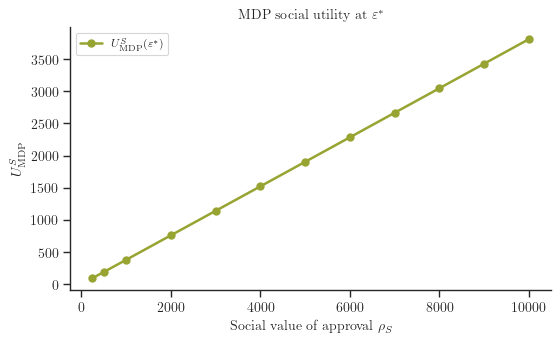

In [18]:
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

ax.plot(rho_S_range, us_mdp, 'o-', color=palette[1],
        linewidth=1.8, markersize=5, label=r'$U^S_{\mathrm{MDP}}(\varepsilon^*)$')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'$U^S_{\mathrm{MDP}}$')
ax.set_title(r'MDP social utility at $\varepsilon^*$')
ax.legend(fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'us_mdp_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'us_mdp_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 3. True social utility $U^S_{\text{true}}$ vs $\rho_S$ (one curve per $\theta^*$)

For each $\theta^*$, the true social utility at the MDP-optimal subsidy $\varepsilon^*(\rho_S)$ is
$$
U^S_{\text{true}}(\varepsilon^*;\pi^*,\theta^*) = \rho_S\,P_{\text{true}}(\theta^*) - \varepsilon^* A_{\text{true}}(\theta^*)
$$
estimated via Monte Carlo under Binomial$(n, \theta^*)$ rollouts.

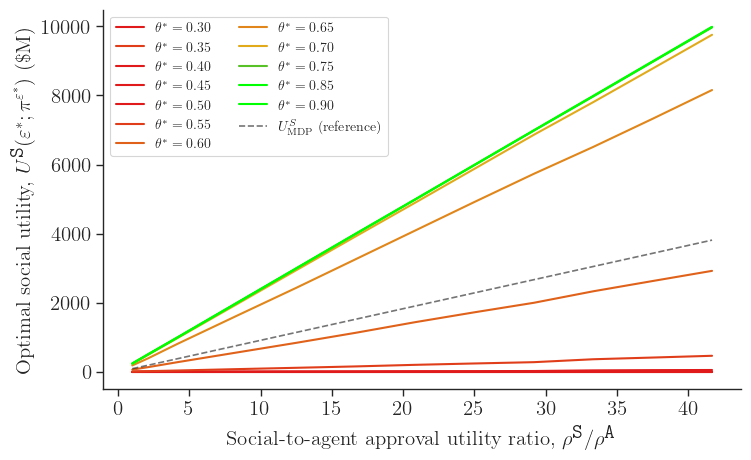

In [19]:
width_pt = 1000
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# One color per theta* value, red -> green (edit freely)
line_colors = [
    '#e01a1a',  # 0.30
    '#e03e1a',  # 0.35
    '#e01a1a',  # 0.40
    '#e01a1a',  # 0.45
    '#e01a1a',  # 0.50
    '#e03e1a',  # 0.55
    '#e0621a',  # 0.60
    '#e0861a',  # 0.65
    '#e0aa1a',  # 0.70
    "#58c128",  # 0.75
    '#00ff00',  # 0.85
    "#00ff00",  # 0.90
]

for j, theta_star in enumerate(theta_star_range):
    ax.plot(x_ratio, us_true[:, j],
            color=line_colors[j], linewidth=1.5,
            label=fr'$\theta^*={theta_star:.2f}$')

# Overlay MDP social utility for comparison
ax.plot(x_ratio, us_mdp, 'k--', linewidth=1.2, alpha=0.6,
        label=r'$U^S_{\mathrm{MDP}}$ (reference)')

ax.legend(fontsize=10, ncol=2, loc='best')

ax.set_ylabel(r'Optimal social utility, $U^{\texttt{S}}(\varepsilon^*;\pi^{\varepsilon^*})$ (\$M)', fontsize=15)
ax.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=15)
ax.set_xticks(range(0, 41, 5))
ax.tick_params(axis='both', labelsize=15)

sns.despine()
plt.tight_layout()
plt.show()


fig.savefig(os.path.join(figures_dir, 'us_true_vs_rhoS.pdf'), bbox_inches='tight')
